In [1]:
#Install requirements
%pip install -r "../requirements.txt"

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix, 
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    ConfusionMatrixDisplay)

import scipy
from scipy.stats import pearsonr

In [3]:
#Import the data-feature matrices generated in Task 1

#Load Training Data
X_train_metadata = pd.read_pickle('../data/processed/X_train_metadata.pkl')
X_train_cpg = pd.read_pickle('../data/processed/X_train_cpg.pkl')
X_train_final = pd.read_pickle('../data/processed/X_train_final.pkl')
y_train = pd.read_pickle('../data/processed/y_train.pkl')

#Load Validation Data
X_val_metadata = pd.read_pickle('../data/processed/X_val_metadata.pkl')
X_val_cpg = pd.read_pickle('../data/processed/X_val_cpg.pkl')
X_val_final = pd.read_pickle('../data/processed/X_val_final.pkl')
y_val = pd.read_pickle('../data/processed/y_val.pkl')

print('Data for training and validation set loaded successfully')


Data for training and validation set loaded successfully


In [4]:
#Train OLS for the feature matrices of the training set

#Metadata_Matrix
#Initialize and Fit
metadata_OLS = LinearRegression().fit(X_train_metadata, y_train)

#Get predictions using the validation set
y_pred_metadata = metadata_OLS.predict(X_val_metadata)

#Score
metadata_OLS_r2 = metadata_OLS.score(X_train_metadata, y_train)
print(f"Training R^2 for the Metadata features: {metadata_OLS_r2:.4f}")

Training R^2 for the Metadata features: 0.2209


In [5]:
#CpG Matrix
#Initialize and Fit
cpg_OLS = LinearRegression().fit(X_train_cpg, y_train)

#Get predictions using the validation set
y_pred_cpg = cpg_OLS.predict(X_val_cpg)

#Score
cpg_OLS_r2 = cpg_OLS.score(X_train_cpg, y_train)
print(f"Training R^2 for the CpG features: {cpg_OLS_r2:.4f}")

Training R^2 for the CpG features: 1.0000


In [6]:
#Combined_Matrix
#Initialize and Fit
combined_OLS = LinearRegression().fit(X_train_final, y_train)

#Get predictions using the validation set
y_pred_combined = combined_OLS.predict(X_val_final)

#Score
combined_OLS_r2 = combined_OLS.score(X_train_final, y_train)
print(f"Training R^2 for the Combined features: {combined_OLS_r2:.4f}")

Training R^2 for the Combined features: 1.0000


In [7]:
import os
import sys

#Add the src to the path
sys.path.append(os.path.abspath(os.path.join('..')))

In [8]:
#Bootstrap Resampling for validation

from src.functions import bootstrap_apply

#For the Metadata Features
bootstrap_metadata = bootstrap_apply(y_pred_metadata, y_val)
bootstrap_metadata_mean = bootstrap_metadata.mean()
bootstrap_metadata_95CI = bootstrap_metadata.quantile([0.025, 0.975])

print(f"The OLS Metadata Baseline Statistics")
print(bootstrap_metadata_mean)
print("\n 95% CI")
print(bootstrap_metadata_95CI)

The OLS Metadata Baseline Statistics
RMSE         11.823112
MAE           9.260137
R2            0.230310
Pearson_r     0.496823
dtype: float64

 95% CI
            RMSE        MAE        R2  Pearson_r
0.025   9.781794   7.808998  0.052702    0.32818
0.975  14.030719  10.780711  0.388125    0.64812


In [9]:
#For the CpG Features
bootstrap_cpg = bootstrap_apply(y_pred_cpg, y_val)
bootstrap_cpg_mean = bootstrap_cpg.mean()
bootstrap_cpg_95CI = bootstrap_cpg.quantile([0.025, 0.975])

print(f"The OLS CpG Baseline Statistics")
print(bootstrap_cpg_mean)
print("\n 95% CI")
print(bootstrap_cpg_95CI)

The OLS CpG Baseline Statistics
RMSE         5.456697
MAE          4.073278
R2           0.832755
Pearson_r    0.920595
dtype: float64

 95% CI
           RMSE       MAE        R2  Pearson_r
0.025  4.342181  3.419739  0.741831   0.881571
0.975  6.757622  4.849924  0.901156   0.950830


In [10]:
#For the Combined Features
bootstrap_combined = bootstrap_apply(y_pred_combined, y_val)
bootstrap_combined_mean = bootstrap_combined.mean()
bootstrap_combined_95CI = bootstrap_combined.quantile([0.025, 0.975])

print(f"The OLS Combined Baseline Statistics")
print(bootstrap_combined_mean)
print("\n 95% CI")
print(bootstrap_combined_95CI)

The OLS Combined Baseline Statistics
RMSE         5.429341
MAE          4.058774
R2           0.834492
Pearson_r    0.921153
dtype: float64

 95% CI
           RMSE       MAE        R2  Pearson_r
0.025  4.320409  3.407241  0.746823   0.883016
0.975  6.708650  4.838786  0.901596   0.951183


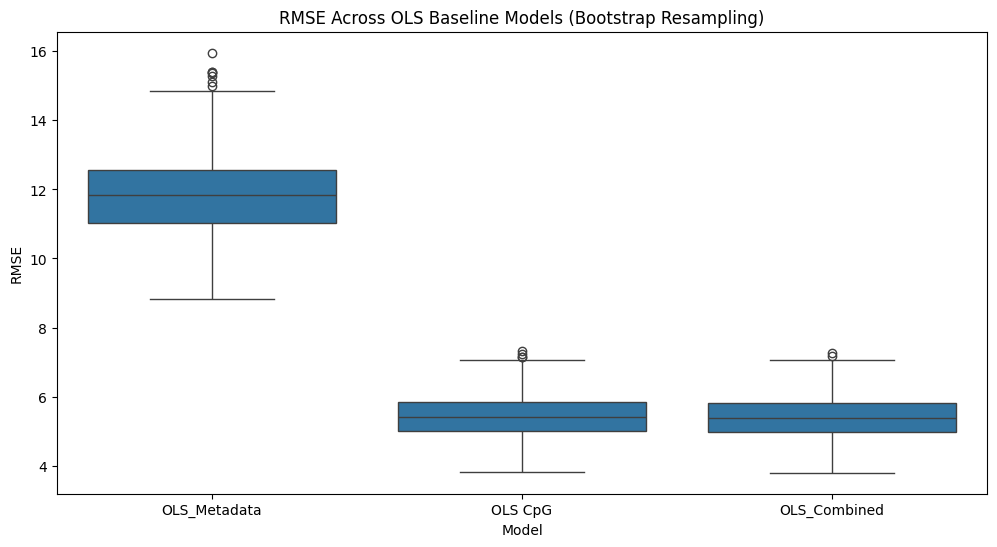

In [ ]:
#Compare the 3 baseline models (RMSE, R2)


baseline_results = pd.concat([
    bootstrap_metadata.assign(Model='OLS_Metadata'),
    bootstrap_cpg.assign(Model='OLS CpG'),
    bootstrap_combined.assign(Model='OLS_Combined')])

#RMSE Boxplot for the baseline models 
plt.figure(figsize=(12,6))
sns.boxplot(data=baseline_results, x='Model', y='RMSE')
plt.title('RMSE Across OLS Baseline Models (Bootstrap Resampling)')
plt.show()

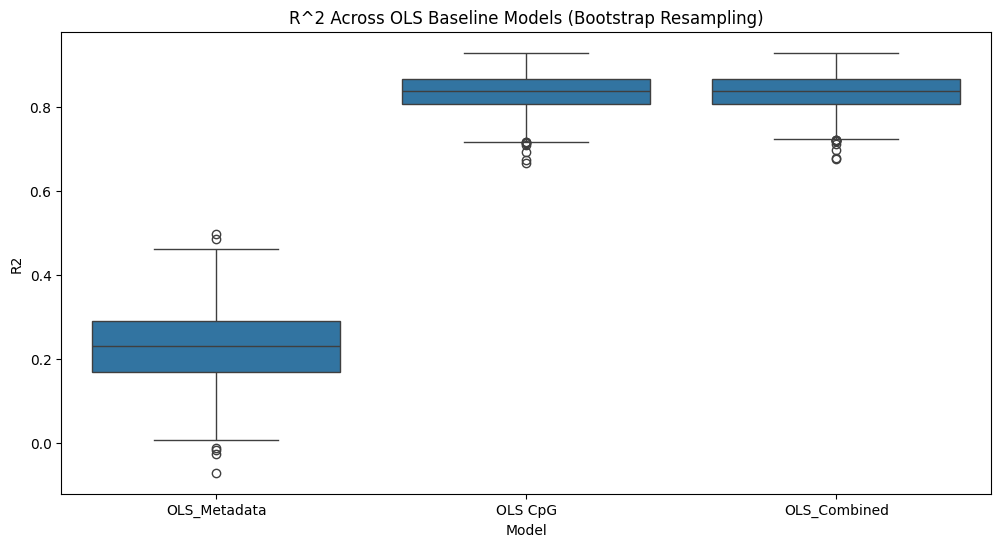

In [13]:
#R2 Boxplot for the baseline models 
plt.figure(figsize=(12,6))
sns.boxplot(data=baseline_results, x='Model', y='R2')
plt.title('R^2 Across OLS Baseline Models (Bootstrap Resampling)')
plt.show()

In [14]:
#Save OLS models 
import joblib

os.makedirs('../models/OLS_Baseline_Models', exist_ok=True)

joblib.dump(metadata_OLS, '../models/OLS_Baseline_Models/metadata_ols_baseline.joblib' )
joblib.dump(cpg_OLS, '../models/OLS_Baseline_Models/cpg_ols_baseline.joblib' )
joblib.dump(combined_OLS, '../models/OLS_Baseline_Models/combined_ols_baseline.joblib' )

['../models/OLS_Baseline_Models/combined_ols_baseline.joblib']